## p27_gradients — tangent dot + arrow sliding along the five P(correct) curves

Uses the five single-parameter curves from `P25_37c` (each with the other four parameters at their trained values,
i.e. `p27_sweep_k/curve.npy`). For each parameter a dot with a tangent arrow slides
**trained value → +2.5 → −2.5 → trained value**, and every frame is written to

```
p27_gradients/param_k/frame_000.png ...   (same 6x6 in @ 300 dpi crop as the p27 curve frames, pixel-identical size)
p27_gradients/param_k/path.npy            (n_frames x 3: theta, P, dP/dtheta)
p27_gradients/param_k/summary.json        (segment frame ranges, style used, w0, color, ...)
```

Work through the **Tuning** section first — it previews frames and a short GIF using the *exact* render function
the final export uses, so what you see is what you get.

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import json, gc, io
from pathlib import Path
from tqdm import tqdm
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.figure import Figure                      # OO figures: never registered with the notebook backend -> no RAM creep
from matplotlib.backends.backend_agg import FigureCanvasAgg
from PIL import Image
from IPython.display import display, Image as IPyImage

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

ROOT      = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin")
SWEEP_DIR = lambda k: ROOT / f'p27_sweep_{k}'          # written by P25_37c
OUT       = ROOT / 'p27_gradients'
SPAN      = 2.5
N_PARAMS  = 5

### Load the five curves

In [3]:
params = {}
for k in range(1, N_PARAMS + 1):
    meta = json.load(open(SWEEP_DIR(k) / 'summary.json'))
    vals, res = np.load(SWEEP_DIR(k) / 'curve.npy')
    assert abs(vals[0] + SPAN) < 1e-9 and abs(vals[-1] - SPAN) < 1e-9, f"sweep {k} span mismatch"
    params[k] = dict(k=k, vals=vals, res=res, w0=meta['w0'], color=meta['color'], theta_label=meta['theta_label'],
                     coord=meta['coord'], layer_num=meta['layer_num'], spline=CubicSpline(vals, res))

print(f"{'k':>2} {'coord':<22} {'L#':>3} {'w0':>8} {'P(w0)':>7} {'dP/dθ(w0)':>10} {'n_pts':>6}  color")
for p in params.values():
    print(f"{p['k']:>2} {str(tuple(p['coord'])):<22} {p['layer_num']:>3} {p['w0']:>8.4f} {p['spline'](p['w0']):>7.4f} "
          f"{p['spline'](p['w0'], 1):>10.4f} {len(p['vals']):>6}  {p['color']}")

 k coord                   L#       w0   P(w0)  dP/dθ(w0)  n_pts  color
 1 (784, 103)               8   0.2151  0.0565     0.1675    128  m
 2 (63, 10, 0, 0)           6   0.0124  0.0565     0.0386    128  #eb8423
 3 (59, 8, 0, 2)            4  -0.0081  0.0565     0.0487    128  #419c52
 4 (34, 14, 2, 1)           3   0.1827  0.0565    -0.0324    128  #ed5e78
 5 (33, 0, 6, 1)            1   0.0995  0.0565     0.0267    128  #d73b2f


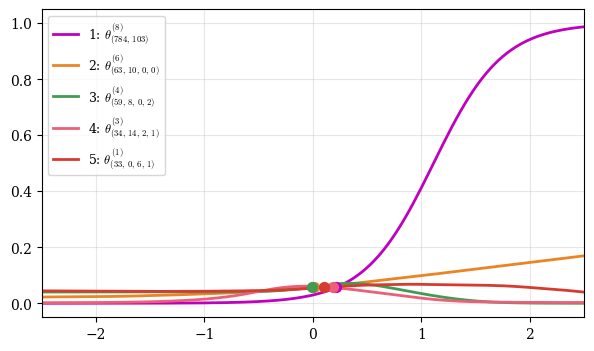

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for p in params.values():
    ax.plot(p['vals'], p['res'], c=p['color'], linewidth=2, label=f"{p['k']}: {p['theta_label']}")
    ax.scatter(p['w0'], p['spline'](p['w0']), c=p['color'], s=50, zorder=10)
ax.set_xlim(-SPAN, SPAN); ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=9);

### Path: trained value → +2.5 → −2.5 → trained value

142 frames {'to_plus': (0, 31), 'to_minus': (31, 102), 'to_home': (102, 142)}


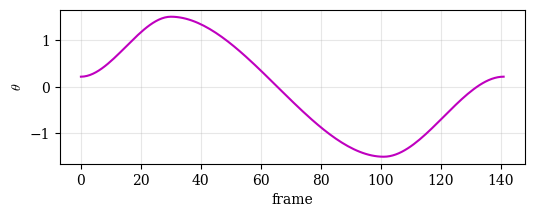

In [5]:
FRAMES_PER_UNIT = 24
EASE            = 'smooth'
HOLD_FRAMES     = 0
PATH_SPAN       = 1.5       # how far the dot travels; SPAN (2.5) still sets the axes

def make_path(w0, frames_per_unit=FRAMES_PER_UNIT, ease=EASE, hold=HOLD_FRAMES, turn=PATH_SPAN):
    '''Returns (theta array, dict of segment -> (start_frame, end_frame_exclusive)).'''
    waypoints = [w0, turn, -turn, w0]
    ...  # rest unchanged
    thetas, segs, pos = [], {}, 0
    for name, (a, b) in zip(['to_plus', 'to_minus', 'to_home'], zip(waypoints[:-1], waypoints[1:])):
        n = max(2, int(round(abs(b - a) * frames_per_unit)))
        t = np.linspace(0, 1, n)
        if ease == 'smooth': t = t * t * (3 - 2 * t)
        seg = a + (b - a) * t
        if thetas: seg = seg[1:]                      # don't repeat the shared waypoint
        thetas.append(seg); segs[name] = (pos, pos + len(seg)); pos += len(seg)
        if hold and name != 'to_home':
            thetas.append(np.full(hold, b)); pos += hold
    return np.concatenate(thetas), segs

th, segs = make_path(params[1]['w0'])
print(len(th), 'frames', segs)
plt.figure(figsize=(6, 2)); plt.plot(th, c=params[1]['color']); plt.xlabel('frame'); plt.ylabel(r'$\theta$'); plt.grid(alpha=0.3);

### Renderer

In [6]:
# curve geometry — identical to render_curve in P25_37c so frames drop in next to the sweep frames
CURVE_FIGSIZE = (6, 6)
CURVE_YLIM    = (-0.05, 1.05)
DPI           = 300

def style_ax(ax, color=CHILL_BROWN, tick_fontsize=12):
    ax.spines[:].set_visible(False)
    ax.tick_params(colors=color, which='both', labelsize=tick_fontsize)

def base_curve_fig(p, style, dpi=DPI):
    fig = Figure(figsize=CURVE_FIGSIZE, facecolor='k', dpi=dpi)
    ax = fig.add_subplot(111, facecolor='k')
    ax.plot(p['vals'], p['res'], linewidth=style['curve_lw'], c=p['color'], alpha=style['curve_alpha'])
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    ax.set_xlim(-SPAN, SPAN); #ax.set_ylim(*CURVE_YLIM) #SW
    style_ax(ax)
    return fig, ax

_bbox_cache = {}
def fixed_bbox(p, style, dpi):
    '''The crop box bbox_inches='tight' would produce for a bare curve, computed once and reused for every frame,
    so an arrow poking past the axes can't change the output size.'''
    if dpi not in _bbox_cache:
        fig, ax = base_curve_fig(p, style, dpi); FigureCanvasAgg(fig)
        _bbox_cache[dpi] = fig.get_tightbbox(fig.canvas.get_renderer()).padded(0.1)
    return _bbox_cache[dpi]

def add_dot_and_tangent(fig, ax, x, y, slope, color, style):
    # tangent direction in *display* space (data aspect isn't 1, so (1, slope) in data units isn't visually tangent)
    p0 = ax.transData.transform((x, y))
    d = ax.transData.transform((x + 1, y + slope)) - p0
    d = d / np.linalg.norm(d) * style['arrow_dir']
    L = style['arrow_len_pt'] * fig.dpi / 72
    if   style['arrow_anchor'] == 'center': tail, head = p0 - d * L / 2, p0 + d * L / 2
    elif style['arrow_anchor'] == 'tail':   tail, head = p0, p0 + d * L
    else:                                   tail, head = p0 - d * L, p0               # 'head': arrow tip on the dot
    inv = ax.transData.inverted()
    effects = [pe.withStroke(linewidth=style['arrow_lw'] + 2 * style['arrow_outline_pt'], foreground='k')] if style['arrow_outline_pt'] else None
    ann = ax.annotate('', xy=inv.transform(head), xytext=inv.transform(tail), annotation_clip=style['arrow_clip'],
                      arrowprops=dict(arrowstyle=style['arrow_style'], color=color, lw=style['arrow_lw'],
                                      mutation_scale=style['arrow_head'], alpha=style['arrow_alpha'],
                                      shrinkA=0, shrinkB=0, path_effects=effects, clip_on=style['arrow_clip']))
    ann.arrow_patch.set_zorder(style['arrow_zorder'])
    ax.scatter(x, y, s=style['dot_size'], c=color, zorder=style['dot_zorder'],
               edgecolors=style['dot_edgecolor'], linewidths=style['dot_edgewidth'])

def render_gradient_frame(p, theta, style, path, dpi=DPI):
    y, slope = float(p['spline'](theta)), float(p['spline'](theta, 1))
    fig, ax = base_curve_fig(p, style, dpi)
    add_dot_and_tangent(fig, ax, theta, y, slope, p['color'], style)
    fig.savefig(path, dpi=dpi, bbox_inches=fixed_bbox(p, style, dpi))
    fig.clear()
    return y, slope

## Tuning

Edit `STYLE`, re-run the preview cells. Sizes are in **points**, so the low-dpi previews are faithful to the 300 dpi export.

| key | what |
|---|---|
| `dot_size` | scatter `s` (points²) — p27 sweep dot is 125 |
| `dot_edgecolor` / `dot_edgewidth` | outline on the dot (`'none'` for none) |
| `arrow_len_pt` | total arrow length |
| `arrow_anchor` | `'center'` (dot in the middle), `'tail'` (arrow leaves the dot), `'head'` (tip touches the dot) |
| `arrow_dir` | `+1` points toward +θ, `-1` toward −θ |
| `arrow_style` | matplotlib arrowstyle: `'-|>'`, `'->'`, `'<|-|>'` (double-headed), `'simple'`, `'fancy'`, `'wedge'` |
| `arrow_lw` / `arrow_head` | shaft width / head size (`mutation_scale`) |
| `arrow_outline_pt` | black halo width around the arrow so it separates from the curve (0 = off) |
| `arrow_alpha`, `arrow_clip` | opacity; clip the arrow at the axes edge |
| `curve_lw`, `curve_alpha` | the underlying curve (3 / 1.0 matches p27) |

In [7]:
STYLE = dict(
    dot_size=175, dot_edgecolor='none', dot_edgewidth=0.0, dot_zorder=12,
    arrow_len_pt=60, arrow_anchor='tail', arrow_dir=+1,
    arrow_style='-|>', arrow_lw=6, arrow_head=20, arrow_outline_pt=0.0, arrow_alpha=1.0, arrow_clip=True, arrow_zorder=11,
    curve_lw=3, curve_alpha=1.0,
)

In [8]:
def preview_grid(style, thetas=None, ks=None, dpi=90, width=260):
    '''Static preview: rows = parameters, cols = theta positions (default: w0, +SPAN, -SPAN, 0).'''
    ks = ks or list(params)
    tiles = []
    for k in ks:
        p = params[k]
        row = []
        for th in (thetas or [p['w0'], PATH_SPAN, -PATH_SPAN, 0.0]):
            buf = io.BytesIO(); render_gradient_frame(p, th, style, buf, dpi=dpi); buf.seek(0)
            im = Image.open(buf).convert('RGB'); row.append(im.resize((width, int(width * im.height / im.width))))
        tiles.append(row)
    W, H = tiles[0][0].size
    sheet = Image.new('RGB', (W * len(tiles[0]), H * len(tiles)), 'black')
    for r, row in enumerate(tiles):
        for c, im in enumerate(row): sheet.paste(im, (c * W, r * H))
    display(sheet)

def preview_gif(style, k=1, n_frames=48, dpi=70, fps=24, width=360):
    '''Animated preview of the full path for one parameter, rendered coarse and fast.'''
    p = params[k]
    th, _ = make_path(p['w0'], frames_per_unit=n_frames / 10)
    frames = []
    for t in th:
        buf = io.BytesIO(); render_gradient_frame(p, t, style, buf, dpi=dpi); buf.seek(0)
        im = Image.open(buf).convert('RGB'); frames.append(im.resize((width, int(width * im.height / im.width))))
    out = io.BytesIO()
    frames[0].save(out, format='GIF', save_all=True, append_images=frames[1:], duration=int(1000 / fps), loop=0)
    display(IPyImage(data=out.getvalue()))

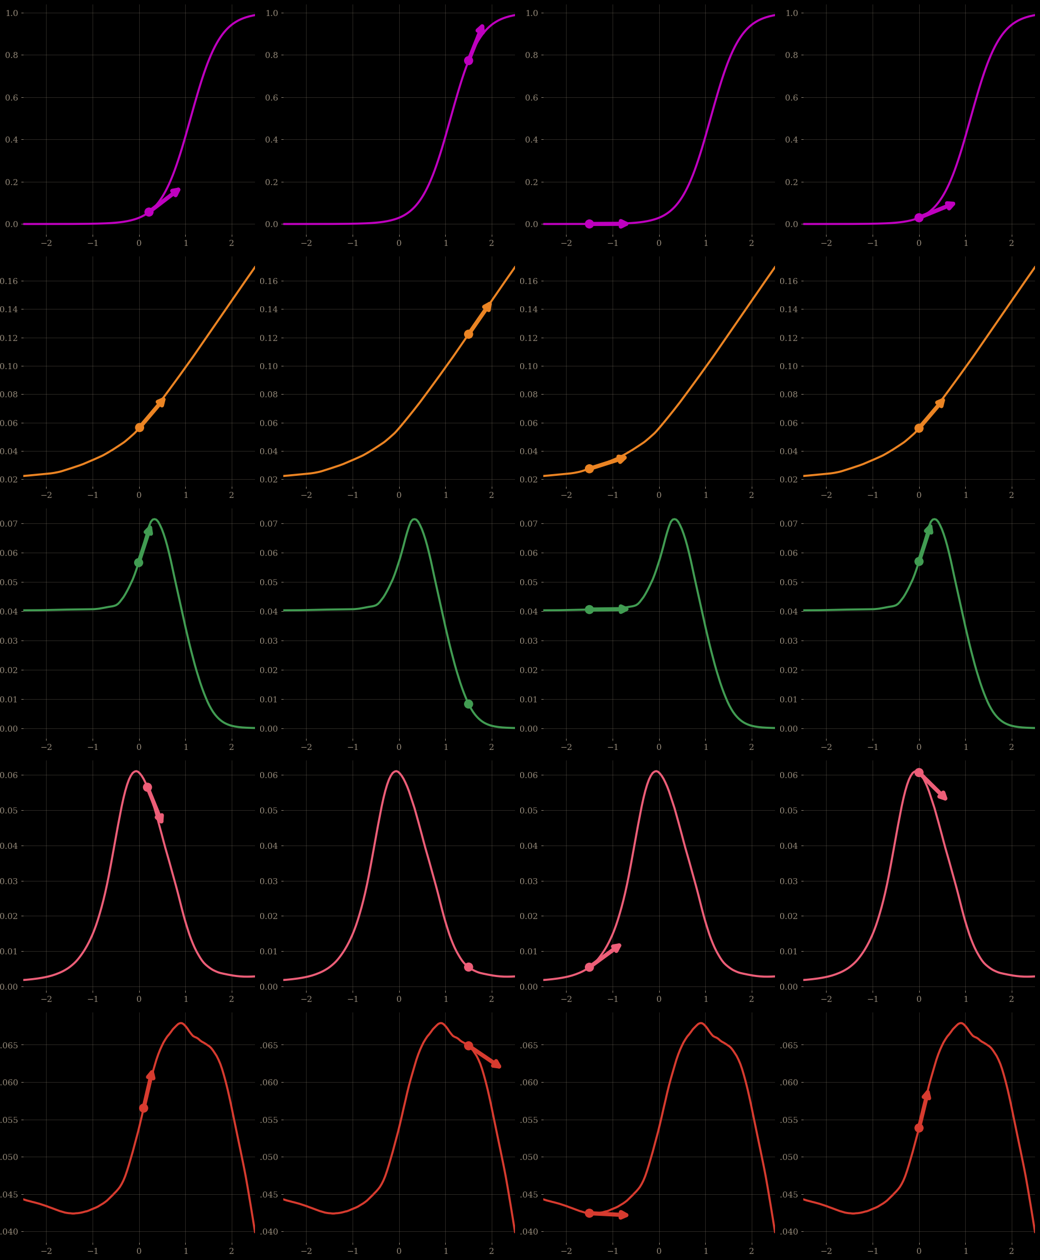

In [9]:
preview_grid(STYLE)

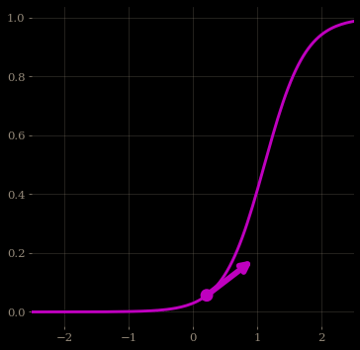

In [10]:
preview_gif(STYLE, k=1)

A few starting points worth trying (paste over `STYLE`):

```python
# arrow leaving the dot, thicker head, black halo so it reads against the curve
STYLE.update(arrow_anchor='tail', arrow_len_pt=70, arrow_lw=3, arrow_head=26, arrow_outline_pt=1.5)

# double-headed tangent line, dot with a thin white rim
STYLE.update(arrow_style='<|-|>', arrow_anchor='center', arrow_len_pt=90, dot_edgecolor='w', dot_edgewidth=1.0)
```

## Final render

In [11]:
FINAL_STYLE = dict(STYLE)   # freeze the tuned values here

def render_param(p, style, out_root=OUT, dpi=DPI):
    d = out_root / f"param_{p['k']}"; d.mkdir(parents=True, exist_ok=True)
    th, segs = make_path(p['w0'])
    rows = np.empty((len(th), 3))
    for i, t in enumerate(tqdm(th, desc=f"param {p['k']} {p['theta_label']}", leave=False)):
        y, s = render_gradient_frame(p, t, style, d / f'frame_{i:03d}.png', dpi=dpi)
        rows[i] = (t, y, s)
        if i % 16 == 0: gc.collect()
    np.save(d / 'path.npy', rows)
    json.dump({'param': p['k'], 'coord': list(p['coord']), 'layer_num': p['layer_num'], 'theta_label': p['theta_label'],
               'w0': p['w0'], 'color': p['color'], 'n_frames': len(th), 'segments': segs,
               'frames_per_unit': FRAMES_PER_UNIT, 'ease': EASE, 'hold_frames': HOLD_FRAMES, 'span': SPAN,
               'style': style, 'source': str(SWEEP_DIR(p['k']) / 'curve.npy')},
              open(d / 'summary.json', 'w'), indent=2)
    return th, segs

for p in params.values():
    render_param(p, FINAL_STYLE)

### Check: every frame the same size, and a strip through one parameter's path

param 1: 170 frames, sizes {(1563, 1524)}
param 2: 170 frames, sizes {(1563, 1524)}
param 3: 170 frames, sizes {(1563, 1524)}
param 4: 171 frames, sizes {(1563, 1524)}
param 5: 171 frames, sizes {(1563, 1524)}


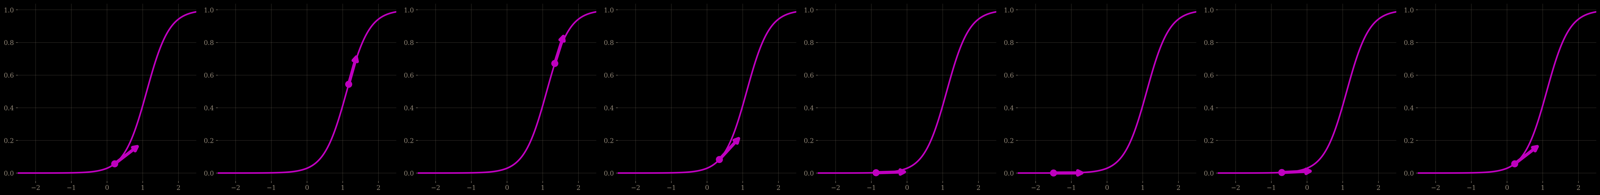

In [12]:
sizes = {}
for k in params:
    d = OUT / f'param_{k}'
    sizes[k] = {Image.open(f).size for f in d.glob('frame_*.png')}
    print(f"param {k}: {len(list(d.glob('frame_*.png')))} frames, sizes {sizes[k]}")
assert all(len(s) == 1 for s in sizes.values()), "frame sizes differ within a parameter!"

k = 1; d = OUT / f'param_{k}'; n = json.load(open(d / 'summary.json'))['n_frames']
picks = np.linspace(0, n - 1, 8).astype(int)
strip = [Image.open(d / f'frame_{i:03d}.png').convert('RGB').resize((200, 195)) for i in picks]
sheet = Image.new('RGB', (200 * len(strip), 195), 'black')
for c, im in enumerate(strip): sheet.paste(im, (c * 200, 0))
display(sheet)